In [1]:
!nvidia-smi

Tue Jun 23 14:28:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P0             27W /   70W |     365MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="mIyQd5Zv6fp1cSaNny9C")
project = rf.workspace("pohs-workspace").project("truck-detection-vka5s-rk5y7")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!pip install ultralytics

In [3]:
import os

print(dataset.location)
print(os.listdir(dataset.location))

/content/truck-detection-1
['test', 'README.roboflow.txt', 'README.dataset.txt', 'data.yaml', 'valid', 'train']


In [ ]:
from ultralytics import YOLO
import cv2
import glob
import os

model = YOLO("yolov8n.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640
)

In [4]:
from ultralytics import YOLO
import cv2
import glob
import os

model = YOLO("/content/runs/detect/train/weights/best.pt")

image_paths = glob.glob(os.path.join(dataset.location, "test", "images", "*.jpg"))
print(image_paths[:5])

image_path = image_paths[0]
image = cv2.imread(image_path)

# results = model(image)[0]

['/content/truck-detection-1/test/images/Image_013224_jpg.rf.97b807ea376875950e2fff2c93892041.jpg', '/content/truck-detection-1/test/images/Image_013524_jpg.rf.c852470264c0e73122b3398684184c22.jpg', '/content/truck-detection-1/test/images/Cutting-Sticker-Truk-Canter-Variasi-3_jpg.rf.21d2fc3914e0d01d9ae835c7a679a725.jpg', '/content/truck-detection-1/test/images/636c52a2-2185-61da-7f4f69e6100998dd_jpg.rf.3d1b2587b0d5ff03acb29782e790474c.jpg', '/content/truck-detection-1/test/images/101_1184_jpg.rf.ac66c2041c496b29a8ab0088209c9a19.jpg']


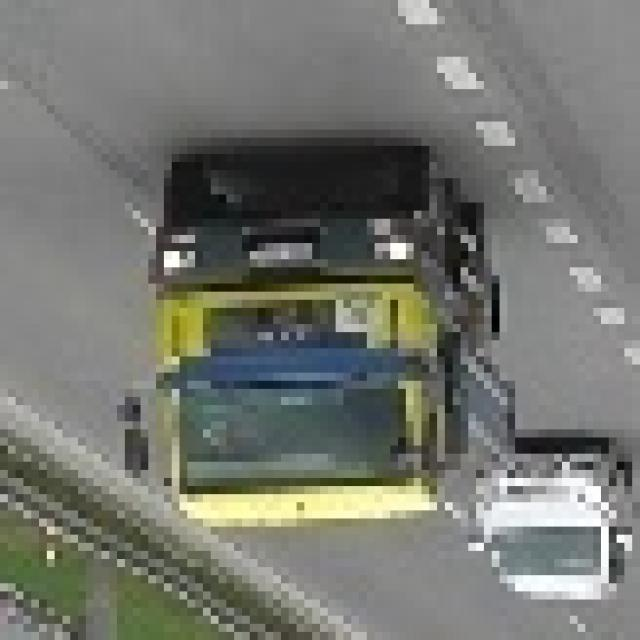

In [8]:
from google.colab.patches import cv2_imshow

original_image = image.copy()
cv2_imshow(original_image)

In [9]:
results = model(image)[0]

print("Number of detections:", len(results.boxes))


0: 640x640 1 truck, 10.1ms
Speed: 3.3ms preprocess, 10.1ms inference, 21.4ms postprocess per image at shape (1, 3, 640, 640)
Number of detections: 1


In [ ]:
!pip install supervision

In [10]:
import supervision as sv

detections = sv.Detections.from_ultralytics(results)

In [11]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = box_annotator.annotate(
    scene=image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections)

In [12]:
labels = [
    f"{class_name} {confidence:.2f}"
    for class_name, confidence
    in zip(detections['class_name'], detections.confidence)
]

In [13]:
annotated_image = box_annotator.annotate(
    scene=image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections, labels=labels)

In [ ]:
print(annotated_image)

Detected:


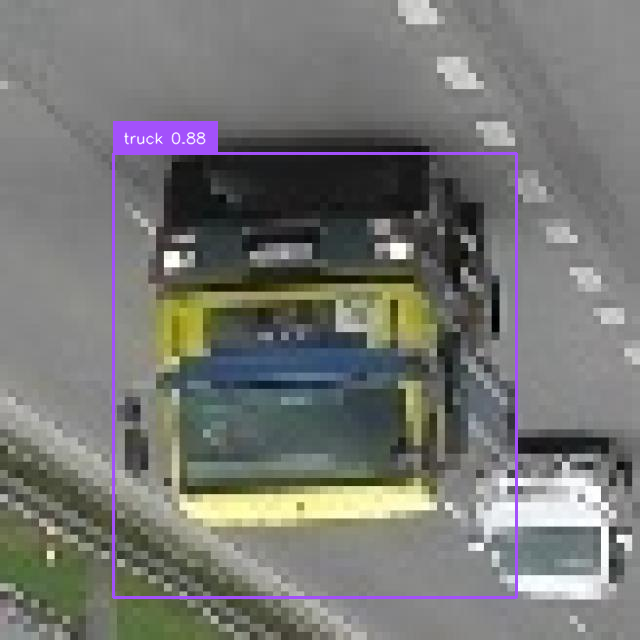

In [14]:
from google.colab.patches import cv2_imshow

print("Detected:")
cv2_imshow(annotated_image)